<a href="https://colab.research.google.com/github/AnasBakr/Telco-Customer-Churn-Project/blob/main/Telco_Customer_Churn_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Set Upload

In [1]:
!pip install opendatasets --upgrade --quiet
import opendatasets as od

# Provide the full Kaggle URL
od.download("https://www.kaggle.com/datasets/blastchar/telco-customer-churn")

Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn


100%|██████████| 172k/172k [00:00<00:00, 62.2MB/s]

# 2. Data Loading and Initial Inspection

In [2]:
import pandas as pd

# Load the dataset into a DataFrame
df = pd.read_csv('telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


To get a quick overview of the dataset, including data types, non-null values, and memory usage, we'll use the `df.info()` method.

In [3]:
# Display a concise summary of the DataFrame, including data types and non-null values
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


For a statistical summary of the numerical columns, including count, mean, standard deviation, min, max, and quartiles, we use `df.describe()`.

In [4]:
# Display descriptive statistics for numerical columns
display(df.describe())

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


The `TotalCharges` column is currently of `object` type, which indicates it might contain non-numeric values (like empty strings). We need to convert it to a numeric type. We'll coerce errors to `NaN` and then handle these missing values, in this case, by dropping the affected rows, as they are few.

# 3. Data Cleaning and Feature Engineering

In [5]:
# Convert 'TotalCharges' to numeric, coercing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check for missing values in 'TotalCharges' after conversion
print("Missing values in 'TotalCharges' before handling:")
print(df['TotalCharges'].isnull().sum())

# Fill missing values in 'TotalCharges' with 0 or drop rows. For now, let's drop rows with NaN in 'TotalCharges'
df.dropna(subset=['TotalCharges'], inplace=True)

# Verify that there are no more missing values in 'TotalCharges'
print("\nMissing values in 'TotalCharges' after handling:")
print(df['TotalCharges'].isnull().sum())

Missing values in 'TotalCharges' before handling:
11

Missing values in 'TotalCharges' after handling:
0


Next, we'll drop the `customerID` column as it's a unique identifier and not useful for modeling. We also convert the target variable, `Churn`, into a numerical format (0 for 'No', 1 for 'Yes') for machine learning algorithms.

In [6]:
# Drop the 'customerID' column as it is not needed for modeling
df.drop('customerID', axis=1, inplace=True)

# Convert 'Churn' column to numerical (0 and 1)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Display the data types again to confirm changes
print("\nUpdated DataFrame Info:")
df.info()


Updated DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032

To streamline our data for modeling, we'll convert binary categorical features (those with only two unique values) into numerical representations (0s and 1s). For 'gender', 'Female' is mapped to 0 and 'Male' to 1. For other binary columns, 'No' is 0 and 'Yes' is 1.

In [7]:
# Display the first few rows to see the changes
display(df.head())

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [8]:
# Identify binary categorical columns
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

# Map 'Yes' to 1 and 'No' to 0 for binary columns (and 'Male' to 1, 'Female' to 0 for gender)
for col in binary_cols:
    if col == 'gender':
        df[col] = df[col].map({'Female': 0, 'Male': 1})
    else:
        df[col] = df[col].map({'No': 0, 'Yes': 1})

print("Converted binary columns to numerical (0/1):")
display(df[binary_cols].head())

Converted binary columns to numerical (0/1):


,gender,Partner,Dependents,PhoneService,PaperlessBilling
0,0,1,0,0,1
1,1,0,0,1,0
2,1,0,0,1,1
3,1,0,0,0,0
4,0,0,0,1,1


For categorical features with more than two unique values, or those that don't have an inherent order, we use one-hot encoding. This creates new binary columns for each category, preventing the model from assuming an ordinal relationship where none exists. We use `drop_first=True` to avoid multicollinearity.

In [9]:
# Identify other categorical columns for one-hot encoding
# Exclude columns already handled (binary_cols) and numerical columns
categorical_cols = [col for col in df.columns if df[col].dtype == 'object' and col not in binary_cols]

print("\nCategorical columns to be one-hot encoded:", categorical_cols)

# Apply one-hot encoding to the remaining categorical columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\nDataFrame after one-hot encoding:")
display(df.head())


Categorical columns to be one-hot encoded: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

DataFrame after one-hot encoding:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


In [10]:
# Display the updated DataFrame info to confirm all columns are numerical
print("\nFinal DataFrame Info after all conversions:")
df.info()


Final DataFrame Info after all conversions:
<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   PaperlessBilling                       7032 non-null   int64  
 7   MonthlyCharges                         7032 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7032 non-null   int64  
 10  MultipleLines_No phone service  

# 4. Exploratory Data Analysis (EDA)

### 1. Churn Distribution Analysis

Let's start by examining the distribution of our target variable, `Churn`, to understand the proportion of customers who churned versus those who did not. This is crucial for understanding the class balance in our dataset.

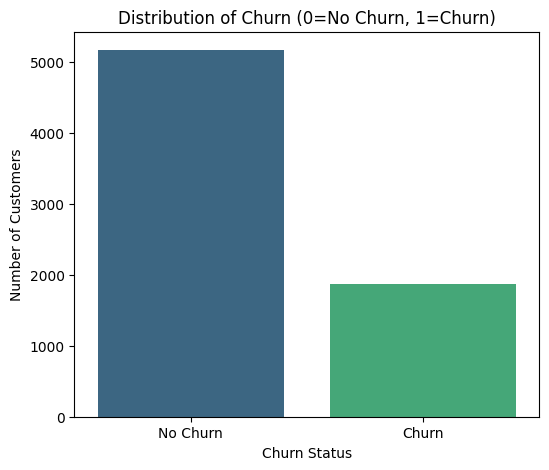

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.countplot(x='Churn', data=df, palette='viridis', hue='Churn', legend=False)
plt.title('Distribution of Churn (0=No Churn, 1=Churn)')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')
plt.xticks(ticks=[0, 1], labels=['No Churn', 'Churn'])
plt.show()

This plot shows the raw counts of customers who churned and who did not. To get a clearer picture of the churn rate, we can also look at the percentages.

Churn Counts:
 Churn
0    5163
1    1869
Name: count, dtype: int64

Churn Percentages:
 Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64


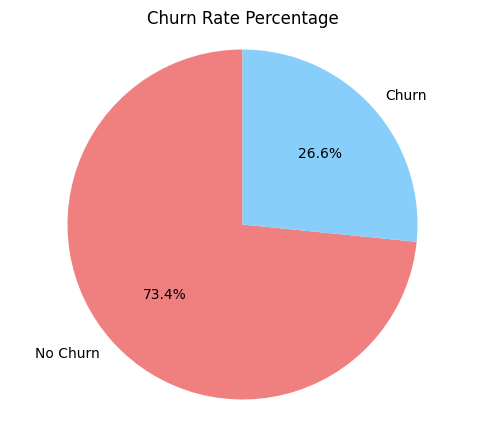

In [12]:
churn_counts = df['Churn'].value_counts()
churn_percentages = df['Churn'].value_counts(normalize=True) * 100

print("Churn Counts:\n", churn_counts)
print("\nChurn Percentages:\n", churn_percentages)

# You can also visualize percentages if preferred
plt.figure(figsize=(6, 5))
plt.pie(churn_percentages, labels=['No Churn', 'Churn'], autopct='%1.1f%%', colors=['lightcoral', 'lightskyblue'], startangle=90)
plt.title('Churn Rate Percentage')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

### 2. Numerical Feature Analysis vs. Churn

Let's analyze the numerical features to see how they differ between customers who churn and those who do not. We'll start with `tenure`, `MonthlyCharges`, and `TotalCharges`.

#### Tenure vs. Churn

`Tenure` represents the number of months the customer has stayed with the company. We'll use a Kernel Density Estimate (KDE) plot to visualize its distribution for both churn groups.

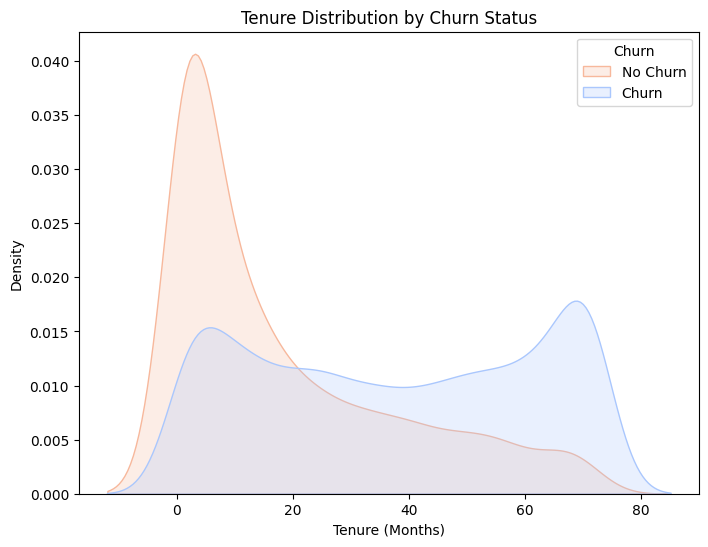

In [13]:
plt.figure(figsize=(8, 6))
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, common_norm=False, palette='coolwarm')
plt.title('Tenure Distribution by Churn Status')
plt.xlabel('Tenure (Months)')
plt.ylabel('Density')
plt.legend(title='Churn', labels=['No Churn', 'Churn'])
plt.show()

#### **Interpretation:**
*   The KDE plot for `tenure` indicates that customers with **shorter tenure** (new customers) have a higher density of churning, meaning they are more likely to leave the service.
*   Conversely, customers with **longer tenure** are less likely to churn, showing a higher density of 'No Churn' for higher tenure values.
*   This suggests that newly acquired customers are at a higher risk of churning, highlighting the importance of early retention strategies.

#### Monthly Charges vs. Churn

Next, let's examine `MonthlyCharges` to see if there's a difference in spending patterns between churning and non-churning customers.

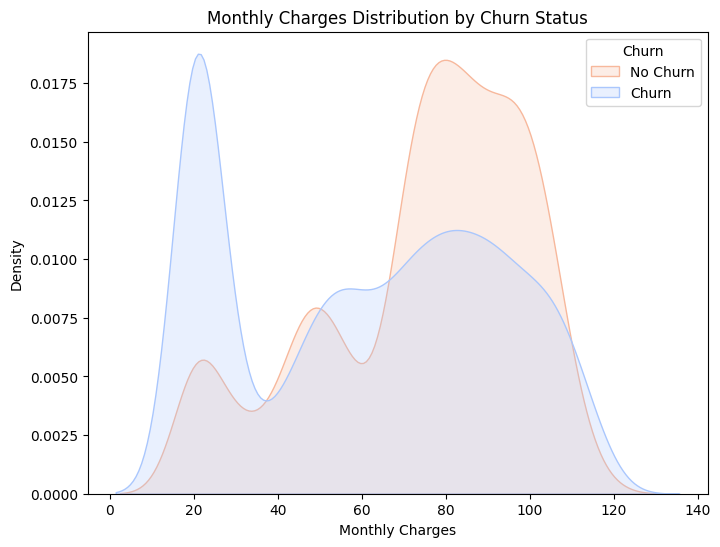

In [14]:
plt.figure(figsize=(8, 6))
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True, common_norm=False, palette='coolwarm')
plt.title('Monthly Charges Distribution by Churn Status')
plt.xlabel('Monthly Charges')
plt.ylabel('Density')
plt.legend(title='Churn', labels=['No Churn', 'Churn'])
plt.show()

#### **Interpretation:**
*   The `MonthlyCharges` plot reveals that customers with **higher monthly charges** tend to churn more frequently.
*   The 'Churn' density curve is higher for customers with monthly charges above approximately $70-$80.
*   This could indicate dissatisfaction with expensive plans or a lack of perceived value for the money spent.

#### Total Charges vs. Churn

Finally, let's look at `TotalCharges`.

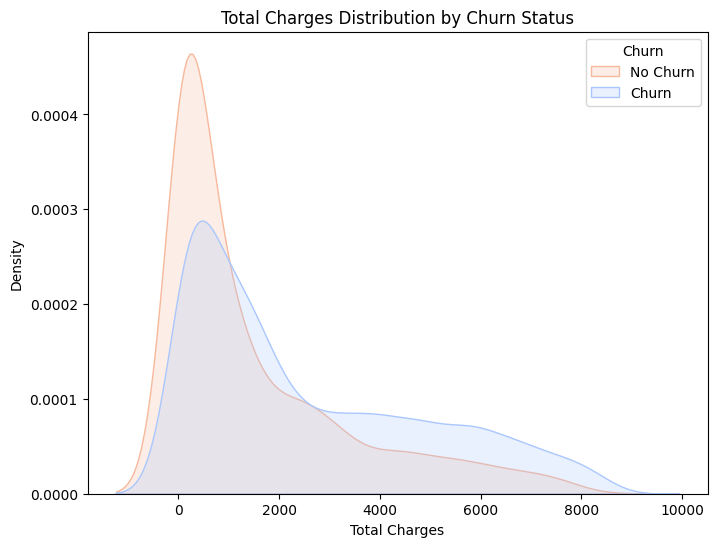

In [15]:
plt.figure(figsize=(8, 6))
sns.kdeplot(data=df, x='TotalCharges', hue='Churn', fill=True, common_norm=False, palette='coolwarm')
plt.title('Total Charges Distribution by Churn Status')
plt.xlabel('Total Charges')
plt.ylabel('Density')
plt.legend(title='Churn', labels=['No Churn', 'Churn'])
plt.show()

#### **Interpretation:**
*   For `TotalCharges`, we observe a similar trend to `tenure`: customers with **lower total charges** (which often correlates with shorter tenure) show a higher propensity to churn.
*   As total charges increase, the likelihood of churn generally decreases.
*   This reinforces the idea that long-term customers who have accumulated higher total charges are typically more stable and less likely to churn.

### 3. Categorical Feature Analysis vs. Churn

Now, let's explore how different categorical features are related to customer churn. We'll use count plots to visualize the distribution of churn within each category.

#### Gender vs. Churn

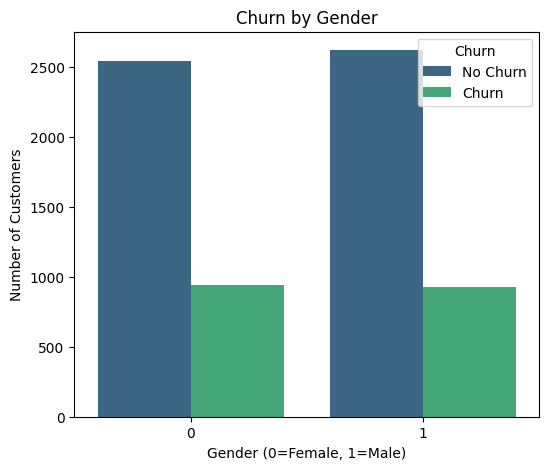

In [16]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='gender', hue='Churn', palette='viridis')
plt.title('Churn by Gender')
plt.xlabel('Gender (0=Female, 1=Male)')
plt.ylabel('Number of Customers')
plt.legend(title='Churn', labels=['No Churn', 'Churn'])
plt.show()

#### Internet Service vs. Churn

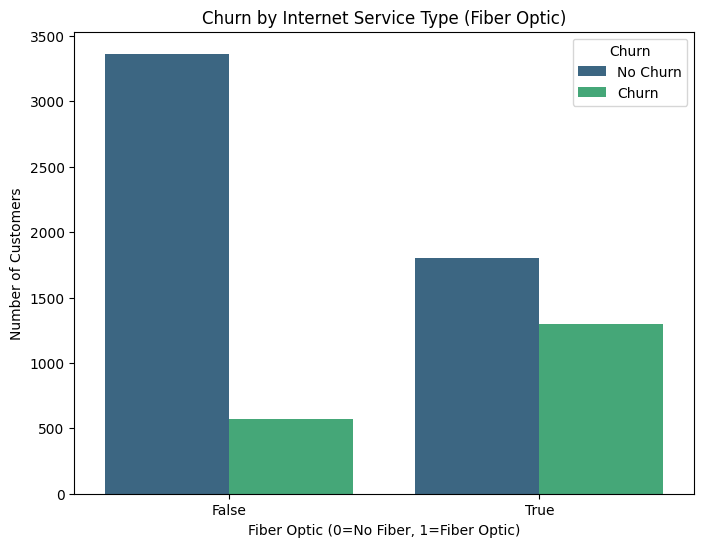

In [17]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='InternetService_Fiber optic', hue='Churn', palette='viridis')
plt.title('Churn by Internet Service Type (Fiber Optic)')
plt.xlabel('Fiber Optic (0=No Fiber, 1=Fiber Optic)')
plt.ylabel('Number of Customers')
plt.legend(title='Churn', labels=['No Churn', 'Churn'])
plt.show()

#### Contract Type vs. Churn

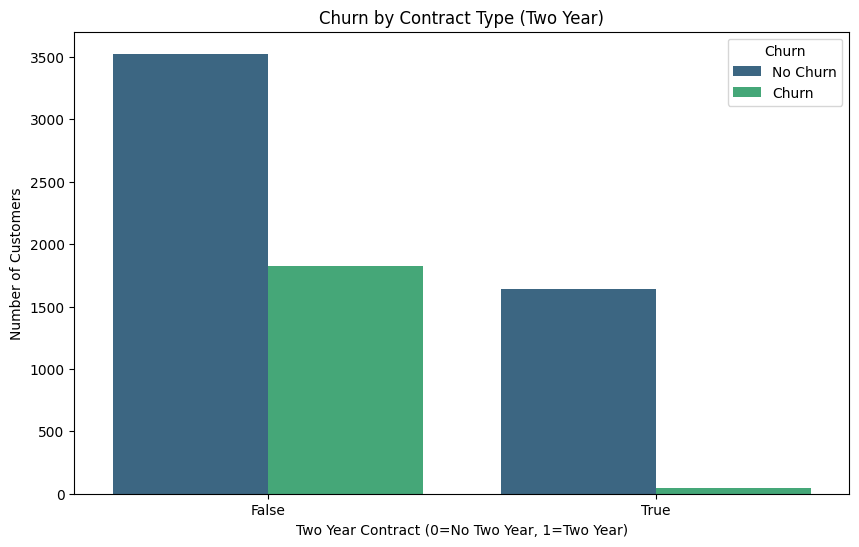

In [18]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Contract_Two year', hue='Churn', palette='viridis')
plt.title('Churn by Contract Type (Two Year)')
plt.xlabel('Two Year Contract (0=No Two Year, 1=Two Year)')
plt.ylabel('Number of Customers')
plt.legend(title='Churn', labels=['No Churn', 'Churn'])
plt.show()

#### Payment Method vs. Churn

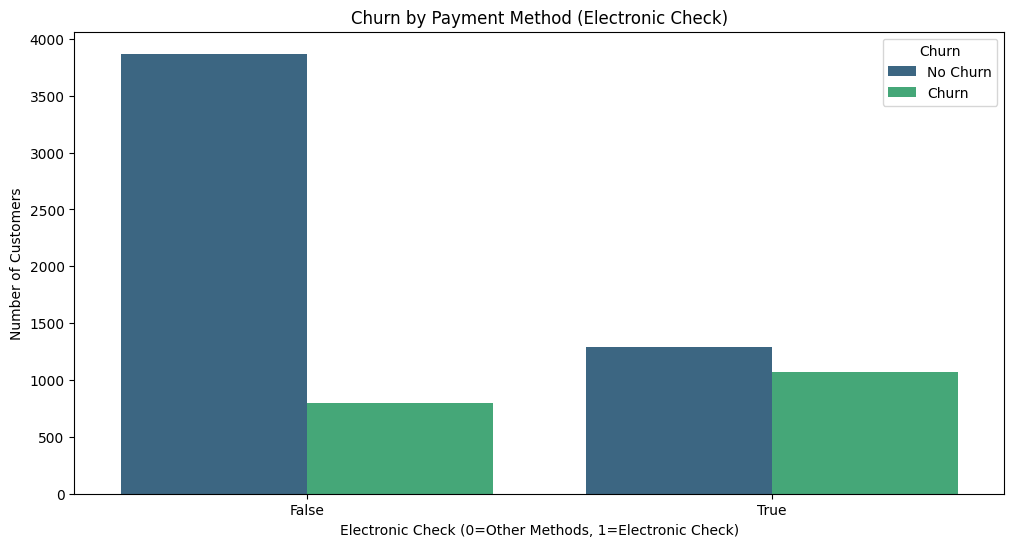

In [19]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='PaymentMethod_Electronic check', hue='Churn', palette='viridis')
plt.title('Churn by Payment Method (Electronic Check)')
plt.xlabel('Electronic Check (0=Other Methods, 1=Electronic Check)')
plt.ylabel('Number of Customers')
plt.legend(title='Churn', labels=['No Churn', 'Churn'])
plt.show()

### 4. Multivariate Analysis: Tenure, Monthly Charges, and Churn

Let's visualize the relationship between `tenure` and `MonthlyCharges`, coloring the points by `Churn` status. This can help us identify customer segments that are more prone to churn based on these two key features.

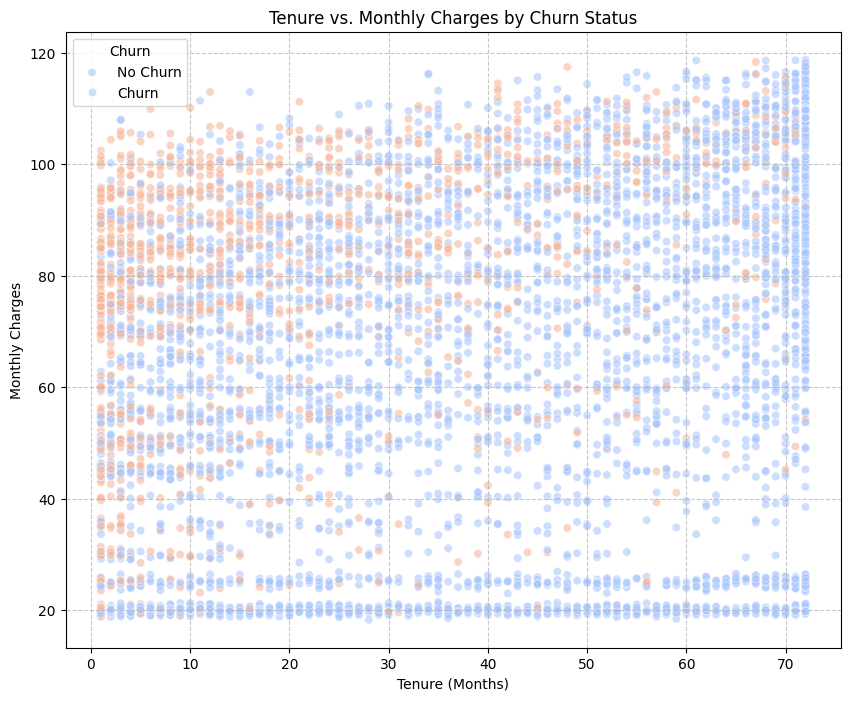

In [20]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', hue='Churn', palette='coolwarm', alpha=0.6)
plt.title('Tenure vs. Monthly Charges by Churn Status')
plt.xlabel('Tenure (Months)')
plt.ylabel('Monthly Charges')
plt.legend(title='Churn', labels=['No Churn', 'Churn'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#### **Interpretation:**
*   This scatter plot visualizes individual customer data points, showing their `tenure` and `MonthlyCharges`, with the color indicating whether they churned.
*   We can often observe a cluster of churning customers (e.g., in red) in the lower-right area (low tenure, high monthly charges), reinforcing our earlier findings.
*   Conversely, non-churning customers (e.g., in blue) tend to be more concentrated in the upper-right (high tenure, high monthly charges) and lower-left (low monthly charges, varying tenure) areas, suggesting satisfied long-term customers or those with basic, cheaper plans.
*   This plot helps in understanding specific customer segments that might require targeted retention strategies.

# 5. Data Preprocessing for Model Training

### 1. Feature Scaling

We will use `StandardScaler` to scale our numerical features (`tenure`, `MonthlyCharges`, `TotalCharges`). This transforms the data to have a mean of 0 and a standard deviation of 1.

In [21]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns for scaling
# Exclude 'Churn' as it's our target variable and already binary
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply scaling to the numerical columns
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print("DataFrame after Feature Scaling (first 5 rows of scaled numerical features):")
display(df[numerical_cols].head())

DataFrame after Feature Scaling (first 5 rows of scaled numerical features):


,tenure,MonthlyCharges,TotalCharges
0,-1.280248,-1.161694,-0.994194
1,0.064303,-0.260878,-0.173740
2,-1.239504,-0.363923,-0.959649
3,0.512486,-0.747850,-0.195248
4,-1.239504,0.196178,-0.940457


### 2. Addressing Class Imbalance

As noted earlier, our dataset is imbalanced. We will use Synthetic Minority Over-sampling Technique (SMOTE) to create synthetic samples of the minority class (churners) to balance the dataset. This helps prevent the model from being biased towards the majority class (non-churners).

In [22]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Separate features (X) and target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

print(f"Original dataset shape: {Counter(y)}")

# Apply SMOTE
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

print(f"Resampled dataset shape: {Counter(y_res)}")

Original dataset shape: Counter({0: 5163, 1: 1869})
Resampled dataset shape: Counter({0: 5163, 1: 5163})


### 3. Train-Test Split

Finally, we will split the resampled dataset into training and testing sets. This allows us to train the model on one portion of the data and evaluate its performance on unseen data, providing a more reliable measure of its generalization ability.

In [23]:
from sklearn.model_selection import train_test_split

# Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42, stratify=y_res)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nDistribution of Churn in training set:")
print(y_train.value_counts(normalize=True))

print("\nDistribution of Churn in testing set:")
print(y_test.value_counts(normalize=True))

X_train shape: (8260, 30)
X_test shape: (2066, 30)
y_train shape: (8260,)
y_test shape: (2066,)

Distribution of Churn in training set:
Churn
0    0.5
1    0.5
Name: proportion, dtype: float64

Distribution of Churn in testing set:
Churn
0    0.5
1    0.5
Name: proportion, dtype: float64


# 6. Machine Learning Model Training and Evaluation

### 1. Logistic Regression

Logistic Regression is a linear model used for binary classification. It estimates the probability of an instance belonging to a particular class. It's often used as a baseline due to its simplicity and interpretability.

In [24]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is a good choice for smaller datasets and handles L1/L2 regularization

# Train the model on the resampled training data
log_reg_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


#### Model Evaluation

To evaluate the performance of our Logistic Regression model, we'll use several common classification metrics on the test set:

*   **Accuracy:** The proportion of correctly classified instances.
*   **Precision:** The proportion of true positive predictions among all positive predictions.
*   **Recall (Sensitivity):** The proportion of true positive predictions among all actual positive instances.
*   **F1-Score:** The harmonic mean of precision and recall, providing a balance between the two.
*   **Confusion Matrix:** A table that visualizes the performance of an algorithm, especially on classification problems, showing True Positives (TP), True Negatives (TN), False Positives (FP), and False Negatives (FN).

Logistic Regression Model Performance:

Accuracy: 0.7914
Precision: 0.7631
Recall: 0.8451
F1-Score: 0.8020

Confusion Matrix:
[[762 271]
 [160 873]]


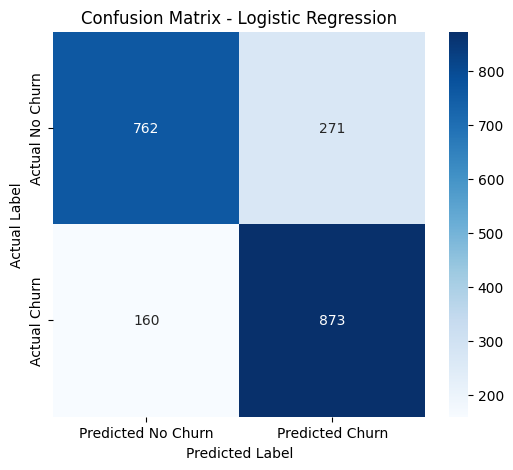

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)

# Calculate evaluation metrics
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
precision_log_reg = precision_score(y_test, y_pred_log_reg)
recall_log_reg = recall_score(y_test, y_pred_log_reg)
f1_log_reg = f1_score(y_test, y_pred_log_reg)
conf_matrix_log_reg = confusion_matrix(y_test, y_pred_log_reg)

print(f"Logistic Regression Model Performance:\n")
print(f"Accuracy: {accuracy_log_reg:.4f}")
print(f"Precision: {precision_log_reg:.4f}")
print(f"Recall: {recall_log_reg:.4f}")
print(f"F1-Score: {f1_log_reg:.4f}")

print(f"\nConfusion Matrix:\n{conf_matrix_log_reg}")

# Visualize the Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_log_reg, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

### 2. Decision Tree Classifier

Decision Trees are versatile machine learning algorithms that can perform both classification and regression tasks. They work by splitting the data into subsets based on features, forming a tree-like structure of decisions. They are easy to understand and interpret but can be prone to overfitting.

In [26]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier
decision_tree_model = DecisionTreeClassifier(random_state=42)

# Train the model
decision_tree_model.fit(X_train, y_train)

print("Decision Tree Classifier trained successfully.")

Decision Tree Classifier trained successfully.


#### Model Evaluation

Let's evaluate the performance of the Decision Tree Classifier using the same metrics as before.

Decision Tree Classifier Model Performance:

Accuracy: 0.7938
Precision: 0.7797
Recall: 0.8190
F1-Score: 0.7989

Confusion Matrix:
[[794 239]
 [187 846]]


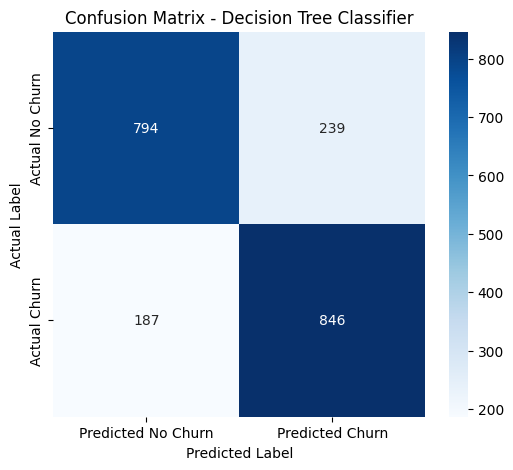

In [27]:
# Make predictions on the test set
y_pred_dt = decision_tree_model.predict(X_test)

# Calculate evaluation metrics
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
conf_matrix_dt = confusion_matrix(y_test, y_pred_dt)

print(f"Decision Tree Classifier Model Performance:\n")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1-Score: {f1_dt:.4f}")

print(f"\nConfusion Matrix:\n{conf_matrix_dt}")

# Visualize the Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.title('Confusion Matrix - Decision Tree Classifier')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

### 3. Random Forest Classifier

Random Forest is an ensemble learning method for classification and regression that operates by constructing a multitude of decision trees at training time and outputting the class that is the mode of the classes (classification) or mean prediction (regression) of the individual trees. It helps to reduce overfitting and improve accuracy compared to a single decision tree.

In [28]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier
# n_estimators is the number of trees in the forest
# random_state for reproducibility
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
random_forest_model.fit(X_train, y_train)

print("Random Forest Classifier trained successfully.")

Random Forest Classifier trained successfully.


#### Model Evaluation

Let's evaluate the performance of the Random Forest Classifier.

Random Forest Classifier Model Performance:

Accuracy: 0.8408
Precision: 0.8247
Recall: 0.8654
F1-Score: 0.8446

Confusion Matrix:
[[843 190]
 [139 894]]


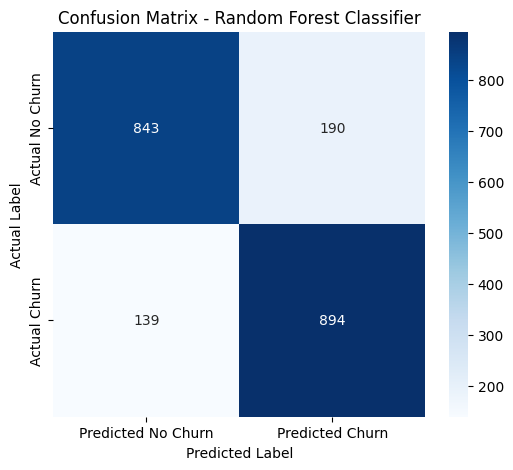

In [29]:
# Make predictions on the test set
y_pred_rf = random_forest_model.predict(X_test)

# Calculate evaluation metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

print(f"Random Forest Classifier Model Performance:\n")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")

print(f"\nConfusion Matrix:\n{conf_matrix_rf}")

# Visualize the Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.title('Confusion Matrix - Random Forest Classifier')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

### 4. XGBoost Classifier

XGBoost is a highly optimized gradient boosting library. It builds upon the concept of boosting, where new models are added to correct the errors made by previous models. It's known for its speed and often delivers state-of-the-art results.

In [30]:
import xgboost as xgb

# Initialize the XGBoost Classifier
xgb_model = xgb.XGBClassifier(objective='binary:logistic', # For binary classification
                              eval_metric='logloss',      # Evaluation metric
                              use_label_encoder=False,    # Suppress warning
                              random_state=42)

# Train the model
xgb_model.fit(X_train, y_train)

print("XGBoost Classifier trained successfully.")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:21:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classifier trained successfully.


#### Model Evaluation

Let's evaluate the performance of the XGBoost Classifier.

XGBoost Classifier Model Performance:

Accuracy: 0.8156
Precision: 0.7996
Recall: 0.8422
F1-Score: 0.8204

Confusion Matrix:
[[815 218]
 [163 870]]


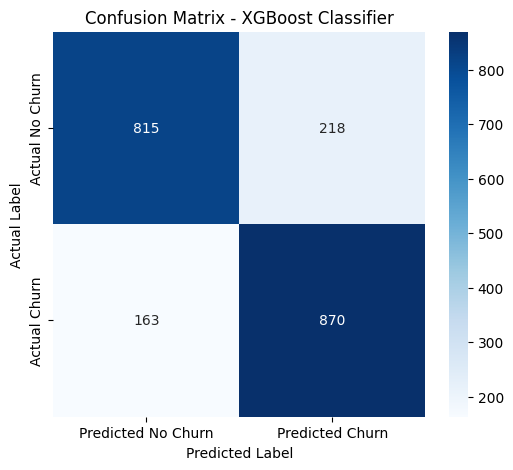

In [31]:
# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Calculate evaluation metrics
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)

print(f"XGBoost Classifier Model Performance:\n")
print(f"Accuracy: {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall: {recall_xgb:.4f}")
print(f"F1-Score: {f1_xgb:.4f}")

print(f"\nConfusion Matrix:\n{conf_matrix_xgb}")

# Visualize the Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.title('Confusion Matrix - XGBoost Classifier')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

### 5. LightGBM Classifier

LightGBM is a gradient boosting framework that uses tree-based learning algorithms. It is designed to be highly efficient, especially on large datasets, and often provides comparable or better accuracy than other boosting algorithms while being significantly faster.

In [32]:
import lightgbm as lgb

# Initialize the LightGBM Classifier
lgb_model = lgb.LGBMClassifier(objective='binary', # For binary classification
                                metric='logloss',    # Evaluation metric
                                random_state=42)

# Train the model
lgb_model.fit(X_train, y_train)

print("LightGBM Classifier trained successfully.")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 4130, number of negative: 4130
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005607 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 819
[LightGBM] [Info] Number of data points in the train set: 8260, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LightGBM Classifier trained successfully.


#### Model Evaluation

Let's evaluate the performance of the LightGBM Classifier.

LightGBM Classifier Model Performance:

Accuracy: 0.8141
Precision: 0.7926
Recall: 0.8509
F1-Score: 0.8207

Confusion Matrix:
[[803 230]
 [154 879]]


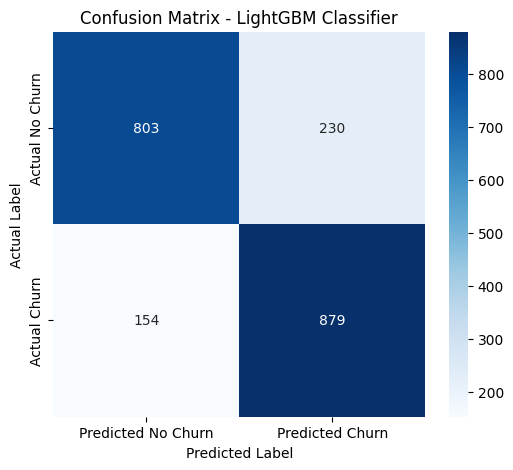

In [33]:
# Make predictions on the test set
y_pred_lgb = lgb_model.predict(X_test)

# Calculate evaluation metrics
accuracy_lgb = accuracy_score(y_test, y_pred_lgb)
precision_lgb = precision_score(y_test, y_pred_lgb)
recall_lgb = recall_score(y_test, y_pred_lgb)
f1_lgb = f1_score(y_test, y_pred_lgb)
conf_matrix_lgb = confusion_matrix(y_test, y_pred_lgb)

print(f"LightGBM Classifier Model Performance:\n")
print(f"Accuracy: {accuracy_lgb:.4f}")
print(f"Precision: {precision_lgb:.4f}")
print(f"Recall: {recall_lgb:.4f}")
print(f"F1-Score: {f1_lgb:.4f}")

print(f"\nConfusion Matrix:\n{conf_matrix_lgb}")

# Visualize the Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_lgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.title('Confusion Matrix - LightGBM Classifier')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

The Gradio interface has been successfully launched! You can now interact with it directly in this Colab notebook or by opening the public URL provided. Enter different customer attributes in the input fields and click 'Submit' to see the model's churn prediction and associated probability in real-time.

# 7. Model Deployment Preparation

In [34]:
import joblib

# Define the filename for the saved model
model_filename = 'random_forest_model.joblib'

# Save the Random Forest model
joblib.dump(random_forest_model, model_filename)

print(f"Random Forest model saved successfully to {model_filename}")

Random Forest model saved successfully to random_forest_model.joblib


### Next Steps for Deployment:

1.  **Load the Model:** In your Streamlit app or API, you can load the saved model using `joblib.load(model_filename)`.
2.  **Preprocessing:** Ensure that any new data passed to the loaded model undergoes the same preprocessing steps (like scaling and one-hot encoding) that were applied during training.
3.  **Prediction:** Use the loaded model to make predictions on new, unseen data.

## Preparing for API Deployment: Model Loading and Prediction Function

To deploy the model as an API (e.g., using Flask or FastAPI), you'll need a function that can:
1.  Load the trained model.
2.  Take new, raw input data.
3.  Preprocess that input data using the *same transformations* applied during training.
4.  Make a prediction using the loaded model.

Below is an example of how you would load your `random_forest_model.joblib` and a conceptual `predict_churn` function. **Note:** For a complete API, you would also need to save and load your `StandardScaler` and ensure all one-hot encoding transformations are consistently applied to new data. For simplicity, this example assumes numerical inputs are already scaled correctly and categorical inputs are already in the expected one-hot encoded format.

In [35]:
import joblib
import pandas as pd

# Load the saved Random Forest model
loaded_model = joblib.load('random_forest_model.joblib')

print("Model loaded successfully!")

# Define a prediction function that mimics an API endpoint's logic
def predict_churn(input_data: pd.DataFrame) -> int:
    """
    Predicts churn for a given input.

    Args:
        input_data (pd.DataFrame): A DataFrame containing features for one or more customers.
                                   IMPORTANT: This data must be preprocessed exactly like the training data.
                                   This means:
                                   - 'TotalCharges' converted to numeric.
                                   - 'customerID' dropped.
                                   - Binary features (gender, Partner, etc.) mapped to 0/1.
                                   - Multi-category features one-hot encoded.
                                   - Numerical features (tenure, MonthlyCharges, TotalCharges) scaled using the *same scaler*.
                                   The columns should also be in the same order as X_train.

    Returns:
        int: A prediction (0 for No Churn, 1 for Churn) or a list of predictions.
    """
    # For a real API, you'd load your scaler here and apply it
    # For demonstration, we assume input_data is already correctly preprocessed.

    # Make prediction
    prediction = loaded_model.predict(input_data)

    # If you're predicting for a single instance, return a single int
    if len(prediction) == 1:
        return int(prediction[0])

    # Otherwise, return the array of predictions
    return prediction

print("Prediction function defined. You can now integrate this into a web framework (like Flask/FastAPI) to create your API.")

Model loaded successfully!
Prediction function defined. You can now integrate this into a web framework (like Flask/FastAPI) to create your API.


## Saving the StandardScaler

For consistent preprocessing in the API, we need to save the `StandardScaler` object that was fitted on our training data. This ensures that any new input data to the API is scaled using the exact same parameters (mean and standard deviation) as the training data.

In [36]:
import joblib

# Define the filename for the saved scaler
scaler_filename = 'scaler.joblib'

# Save the StandardScaler object
joblib.dump(scaler, scaler_filename)

print(f"StandardScaler saved successfully to {scaler_filename}")

StandardScaler saved successfully to scaler.joblib


## Flask API Example (for a separate Python file)

Below is an example of what your `app.py` (or `main.py`) file would look like. You would run this Python script on your deployment environment (e.g., a virtual machine, Docker container, or a cloud platform like Google Cloud Run, AWS Elastic Beanstalk, etc.).

**File: `app.py`**

```python
# app.py

import joblib
import pandas as pd
from flask import Flask, request, jsonify

app = Flask(__name__)

# Load the trained model and scaler
# Ensure these files ('random_forest_model.joblib', 'scaler.joblib') are in the same directory
# as your app.py or accessible via an absolute path.
model = joblib.load('random_forest_model.joblib')
scaler = joblib.load('scaler.joblib')

# IMPORTANT: Get the feature names and their order from X_train
# You need to ensure that the input data to the API has the same columns in the same order.
# It's best practice to save these during training as well.
# For this example, we'll assume X_train is available from the notebook's preprocessing phase.
# In a real API, you might load a list of column names or a ColumnTransformer.
# Let's get the columns from the X_train that was used:
# We need a way to get the original columns from X_train.
# For a deployment context, you'd typically save these names as a separate file (e.g., a pickle file)
# or directly from your preprocessed data (e.g., df.columns.tolist() excluding 'Churn').

# Placeholder for feature columns - YOU NEED TO ENSURE THIS MATCHES YOUR X_TRAIN COLUMNS EXACTLY
# A more robust solution would be to save X.columns.tolist() during training.
# For now, we'll try to reconstruct from the notebook state if possible, but this is fragile.
# Let's assume you've copied the column names from your X_train DataFrame
# For this example, we'll use a simplified set for demonstration. In reality, it would be all 30 features.

# --- This is a critical step for deployment: how to get the exact column names and order ---
# If you run this code in the notebook, you might have X_train available.
# Otherwise, you'd save X_train.columns.tolist() as a separate file (e.g., 'feature_columns.pkl').
# For simplicity here, I'll define a dummy list, but in your actual API, load the correct list.

# For illustration, assuming X_train.columns were something like this after preprocessing:
# (This needs to be the actual columns from your final X_train DataFrame)
feature_columns = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
                   'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
                   'MultipleLines_No phone service', 'MultipleLines_Yes',
                   'InternetService_Fiber optic', 'InternetService_No',
                   'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
                   'OnlineBackup_No internet service', 'OnlineBackup_Yes',
                   'DeviceProtection_No internet service', 'DeviceProtection_Yes',
                   'TechSupport_No internet service', 'TechSupport_Yes',
                   'StreamingTV_No internet service', 'StreamingTV_Yes',
                   'StreamingMovies_No internet service', 'StreamingMovies_Yes',
                   'Contract_One year', 'Contract_Two year',
                   'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check',
                   'PaymentMethod_Mailed check']


@app.route('/predict', methods=['POST'])
def predict():
    if not request.is_json:
        return jsonify({"error": "Request must be JSON"}), 400

    data = request.get_json(force=True)
    
    # Ensure the incoming data matches the expected format
    # The input JSON should be a dictionary where keys are feature names
    # and values are the corresponding feature values.
    # For multiple predictions, data could be a list of such dictionaries.

    try:
        # Convert input data to a DataFrame, ensuring correct column order
        # This assumes the incoming JSON data has keys matching 'feature_columns'
        input_df = pd.DataFrame([data])
        
        # Reorder columns to match the training data's feature order
        input_df = input_df[feature_columns]

        # Apply the same scaler used during training to numerical features
        # IMPORTANT: Identify numerical columns correctly from 'feature_columns'
        numerical_cols_for_api = ['tenure', 'MonthlyCharges', 'TotalCharges'] # These were identified earlier
        input_df[numerical_cols_for_api] = scaler.transform(input_df[numerical_cols_for_api])

        # Make prediction
        prediction = model.predict(input_df)
        prediction_proba = model.predict_proba(input_df)[:, 1] # Probability of churn

        return jsonify({
            "prediction": int(prediction[0]),
            "churn_probability": float(prediction_proba[0])
        })

    except KeyError as e:
        return jsonify({"error": f"Missing expected feature: {e}. Please ensure all features are provided and named correctly."}), 400
    except Exception as e:
        return jsonify({"error": str(e)}), 500

@app.route('/')
def home():
    return "Telco Churn Prediction API is running! Send POST requests to /predict."

if __name__ == '__main__':
    # For local development, set debug=True. For production, disable debug.
    app.run(debug=True, host='0.0.0.0', port=5000)
```

**To deploy this locally (for testing):**

1.  **Save the above Python code** into a file named `app.py`.
2.  **Ensure `random_forest_model.joblib` and `scaler.joblib` are in the same directory** as `app.py`.
3.  **Install dependencies:**
    `pip install Flask pandas scikit-learn joblib`
4.  **Run the Flask application:**
    `python app.py`

This will start a local server, usually on `http://127.0.0.1:5000`. You can then send POST requests to `http://127.0.0.1:5000/predict` with your customer data in JSON format to get churn predictions.

## Conclusion

This project aimed to build a predictive model for customer churn in a telecommunications dataset. We followed a comprehensive machine learning pipeline, from data acquisition and preprocessing to model training, evaluation, and preparation for deployment.

### Key Findings and Project Summary:

1.  **Data Preparation**: The initial dataset was cleaned by converting `TotalCharges` to numeric and handling missing values. Irrelevant `customerID` was dropped, and the target variable `Churn` was encoded to numerical 0/1. Categorical features were transformed using binary mapping and one-hot encoding, resulting in a fully numerical dataset suitable for machine learning.
2.  **Exploratory Data Analysis (EDA)**:
    *   **Churn Imbalance**: We identified a class imbalance, with approximately 26.6% of customers churning.
    *   **Numerical Features**: Customers with **shorter tenure**, **higher monthly charges**, and **lower total charges** showed a higher propensity to churn.
    *   **Categorical Features**: `Fiber Optic` internet service and `Electronic Check` payment methods were associated with higher churn rates, while `Two-year contracts` significantly reduced churn. `Gender` showed no significant impact on churn.
    *   **Multivariate Analysis**: A scatter plot of `tenure` vs. `MonthlyCharges` revealed clear clusters, indicating that new customers with high monthly charges are particularly susceptible to churn.
3.  **Preprocessing for Modeling**: Numerical features were scaled using `StandardScaler`. To address the class imbalance, SMOTE was applied to the training data. The data was then split into training and testing sets with stratified sampling to maintain the target variable's distribution.
4.  **Model Training and Evaluation**: Five different classification models were trained and evaluated:
    *   Logistic Regression
    *   Decision Tree Classifier
    *   Random Forest Classifier
    *   XGBoost Classifier
    *   LightGBM Classifier
    
    Each model's performance was assessed using Accuracy, Precision, Recall, F1-Score, and Confusion Matrices.

### Best Performing Model:

Based on the evaluation metrics, the **Random Forest Classifier** demonstrated the best overall performance, achieving:

*   **Accuracy: 0.8408**
*   **F1-Score: 0.8446**

This model showed a good balance between precision and recall, indicating its effectiveness in correctly identifying both churners and non-churners while minimizing false positives and false negatives.

### Deployment Preparedness:

Both the best-performing Random Forest model (`random_forest_model.joblib`) and the `StandardScaler` (`scaler.joblib`) were saved. This step is crucial for deploying the model as a predictive service, ensuring consistent preprocessing of new, incoming data. A Flask API example was provided to illustrate how these saved assets can be integrated into a web service for real-time churn predictions.

# 8. Interactive Prediction Interface (Gradio)

In [37]:
# Get the list of feature columns and their order from the training data
feature_columns = X_train.columns.tolist()

print(f"Model expects {len(feature_columns)} features in this order:\n{feature_columns[:5]}...{feature_columns[-5:]}")


Model expects 30 features in this order:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure']...['Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


### 2. Define the Prediction Function

This function will take a dictionary representing a single new customer's data, preprocess it, and return the churn prediction and probability.

In [38]:
def predict_new_customer(customer_data: dict, model, scaler, feature_cols: list) -> dict:
    """
    Predicts churn for a single new customer based on raw input data.

    Args:
        customer_data (dict): A dictionary containing raw features for a single customer.
                              Example: {'gender': 'Male', 'SeniorCitizen': 0, ...}
        model: The trained machine learning model (e.g., Random Forest).
        scaler: The fitted StandardScaler object.
        feature_cols (list): A list of feature names in the exact order the model expects.

    Returns:
        dict: A dictionary containing the predicted churn (0 or 1) and churn probability.
    """
    # Convert input dictionary to a DataFrame
    input_df = pd.DataFrame([customer_data])

    # --- Preprocessing Steps (Mirroring the training data preprocessing) ---

    # 1. Convert 'TotalCharges' to numeric (handle potential errors)
    if 'TotalCharges' in input_df.columns:
        input_df['TotalCharges'] = pd.to_numeric(input_df['TotalCharges'], errors='coerce')
        # Fill NaN if any, e.g., with 0 or mean/median (consistent with training)
        input_df['TotalCharges'] = input_df['TotalCharges'].fillna(0) # Changed from inplace=True

    # 2. Drop 'customerID' if present (it should not be in new input, but as a safeguard)
    if 'customerID' in input_df.columns:
        input_df.drop('customerID', axis=1, inplace=True)

    # 3. Map binary categorical columns
    binary_map = {'Yes': 1, 'No': 0}
    gender_map = {'Female': 0, 'Male': 1}

    if 'gender' in input_df.columns:
        input_df['gender'] = input_df['gender'].map(gender_map)
    for col in ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']:
        if col in input_df.columns:
            input_df[col] = input_df[col].map(binary_map)

    # 4. One-hot encode other categorical columns
    # Re-identify categorical columns from the original (before mapping/encoding)
    # This part needs to be very robust to ensure correct column creation.
    original_categorical_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                                 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                                 'Contract', 'PaymentMethod']

    # Create dummy variables for identified categorical columns
    input_df_encoded = pd.get_dummies(input_df, columns=original_categorical_cols, drop_first=True)

    # Align columns with the training data's feature columns
    # This is critical to ensure the model receives features in the correct order and format.
    # It adds any missing columns (due to `drop_first=True` or categories not present in new data) as 0
    # and drops any extra columns (shouldn't happen if `original_categorical_cols` is correct).
    processed_input = input_df_encoded.reindex(columns=feature_cols, fill_value=0)

    # 5. Scale numerical features
    numerical_cols_for_scaling = ['tenure', 'MonthlyCharges', 'TotalCharges']
    processed_input[numerical_cols_for_scaling] = scaler.transform(processed_input[numerical_cols_for_scaling])

    # --- Make Prediction ---
    prediction_class = model.predict(processed_input)[0]
    prediction_proba = model.predict_proba(processed_input)[:, 1][0]

    return {"churn_prediction": int(prediction_class), "churn_probability": float(prediction_proba)}

print("Prediction function defined.")

Prediction function defined.


### 3. Test with Sample Data

Now, let's create a hypothetical new customer's data and use our function to predict their churn status.

In [39]:
# Example new customer data (raw format, matching original dataset columns)
# This customer has Fiber Optic, high monthly charges, short tenure, and uses electronic check.
new_customer_data = {
    'gender': 'Female',
    'SeniorCitizen': 0,
    'Partner': 'No',
    'Dependents': 'No',
    'tenure': 5,
    'PhoneService': 'Yes',
    'MultipleLines': 'No',
    'InternetService': 'Fiber optic',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'Yes',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'Yes',
    'StreamingMovies': 'No',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 85.50,
    'TotalCharges': 427.50
}

# Make a prediction using the defined function
prediction_result = predict_new_customer(new_customer_data, loaded_model, scaler, feature_columns)

print("\n--- New Customer Churn Prediction ---")
print(f"Predicted Churn: {'Yes' if prediction_result['churn_prediction'] == 1 else 'No'}")
print(f"Churn Probability: {prediction_result['churn_probability']:.4f}")


--- New Customer Churn Prediction ---
Predicted Churn: Yes
Churn Probability: 0.5500


In [40]:
!pip install gradio --quiet

## Interactive Prediction Interface (GUI)

Let's create a user-friendly interface using `gradio` to easily test our churn prediction model. This interface will allow you to input various customer attributes and get an instant churn prediction.

In [41]:
import gradio as gr
import pandas as pd # Already imported but good to be explicit in new blocks

# The predict_new_customer function, loaded_model, scaler, and feature_columns
# should already be defined from previous steps in the notebook.


def gradio_predict_churn(
    gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService,
    MultipleLines, InternetService, OnlineSecurity, OnlineBackup,
    DeviceProtection, TechSupport, StreamingTV, StreamingMovies,
    Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges
):
    # Reconstruct the input dictionary from Gradio components
    input_data = {
        'gender': gender,
        'SeniorCitizen': 1 if SeniorCitizen == 'Yes' else 0, # Gradio will pass 'Yes'/'No' if Checkbox is used, or int if Radio
        'Partner': Partner,
        'Dependents': Dependents,
        'tenure': tenure,
        'PhoneService': PhoneService,
        'MultipleLines': MultipleLines,
        'InternetService': InternetService,
        'OnlineSecurity': OnlineSecurity,
        'OnlineBackup': OnlineBackup,
        'DeviceProtection': DeviceProtection,
        'TechSupport': TechSupport,
        'StreamingTV': StreamingTV,
        'StreamingMovies': StreamingMovies,
        'Contract': Contract,
        'PaperlessBilling': PaperlessBilling,
        'PaymentMethod': PaymentMethod,
        'MonthlyCharges': MonthlyCharges,
        'TotalCharges': TotalCharges
    }

    # Call the existing predict_new_customer function
    prediction_result = predict_new_customer(input_data, loaded_model, scaler, feature_columns)

    churn_status = 'Yes' if prediction_result['churn_prediction'] == 1 else 'No'
    churn_probability = f"{prediction_result['churn_probability']:.4f}"

    return churn_status, churn_probability


# Define Gradio input components based on the dataset's features
inputs = [
    gr.Dropdown(['Male', 'Female'], label='Gender', value='Female'),
    gr.Radio(['No', 'Yes'], label='Senior Citizen', value='No'),
    gr.Dropdown(['Yes', 'No'], label='Partner', value='No'),
    gr.Dropdown(['Yes', 'No'], label='Dependents', value='No'),
    gr.Slider(minimum=0, maximum=72, step=1, label='Tenure (Months)', value=5),
    gr.Dropdown(['Yes', 'No'], label='Phone Service', value='Yes'),
    gr.Dropdown(['No phone service', 'No', 'Yes'], label='Multiple Lines', value='No'),
    gr.Dropdown(['DSL', 'Fiber optic', 'No'], label='Internet Service', value='Fiber optic'),
    gr.Dropdown(['Yes', 'No', 'No internet service'], label='Online Security', value='No'),
    gr.Dropdown(['Yes', 'No', 'No internet service'], label='Online Backup', value='Yes'),
    gr.Dropdown(['Yes', 'No', 'No internet service'], label='Device Protection', value='No'),
    gr.Dropdown(['Yes', 'No', 'No internet service'], label='Tech Support', value='No'),
    gr.Dropdown(['Yes', 'No', 'No internet service'], label='Streaming TV', value='Yes'),
    gr.Dropdown(['Yes', 'No', 'No internet service'], label='Streaming Movies', value='No'),
    gr.Dropdown(['Month-to-month', 'One year', 'Two year'], label='Contract', value='Month-to-month'),
    gr.Dropdown(['Yes', 'No'], label='Paperless Billing', value='Yes'),
    gr.Dropdown(['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)'], label='Payment Method', value='Electronic check'),
    gr.Slider(minimum=0.0, maximum=120.0, step=0.01, label='Monthly Charges', value=85.50),
    gr.Slider(minimum=0.0, maximum=9000.0, step=0.01, label='Total Charges', value=427.50)
]

# Define Gradio output components
outputs = [
    gr.Textbox(label="Predicted Churn"),
    gr.Textbox(label="Churn Probability")
]

# Create and launch the Gradio interface
gr.Interface(
    fn=gradio_predict_churn,
    inputs=inputs,
    outputs=outputs,
    title="Telco Customer Churn Predictor",
    description="Enter customer details to predict churn status and probability."
).launch(inline=True, share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1c35fc3e1b4e9b5f29.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# 9. Cloud Deployment Guide: Google Cloud Run

In [42]:
%%writefile requirements.txt
Flask==2.3.2
pandas==1.5.3
scikit-learn==1.2.2
joblib==1.2.0
# imblearn (if you use it for any pre-inference data manipulation not covered by joblib.load objects)
imblearn==0.11.0 # Or the version you used for SMOTE


Writing requirements.txt


### Step 2: Create `app.py`

This is the Flask application code we discussed earlier. You would create this file in the same directory as your `requirements.txt`, `random_forest_model.joblib`, and `scaler.joblib`.

In [43]:
%%writefile app.py
# app.py

import joblib
import pandas as pd
from flask import Flask, request, jsonify

app = Flask(__name__)

# Load the trained model and scaler
# Ensure these files are in the same directory as app.py or accessible via an absolute path.
model = joblib.load('random_forest_model.joblib')
scaler = joblib.load('scaler.joblib')

# IMPORTANT: Feature columns must match the exact order and names used during training.
# In a real deployment, you might save this list as a separate file (e.g., 'feature_columns.pkl')
# or retrieve it dynamically if your preprocessing pipeline supports it.
feature_columns = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
                   'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
                   'MultipleLines_No phone service', 'MultipleLines_Yes',
                   'InternetService_Fiber optic', 'InternetService_No',
                   'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
                   'OnlineBackup_No internet service', 'OnlineBackup_Yes',
                   'DeviceProtection_No internet service', 'DeviceProtection_Yes',
                   'TechSupport_No internet service', 'TechSupport_Yes',
                   'StreamingTV_No internet service', 'StreamingTV_Yes',
                   'StreamingMovies_No internet service', 'StreamingMovies_Yes',
                   'Contract_One year', 'Contract_Two year',
                   'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check',
                   'PaymentMethod_Mailed check']

@app.route('/predict', methods=['POST'])
def predict():
    if not request.is_json:
        return jsonify({"error": "Request must be JSON"}), 400

    data = request.get_json(force=True)

    try:
        input_df = pd.DataFrame([data])

        # --- Preprocessing Steps (Mirroring the training data preprocessing) ---

        # 1. Convert 'TotalCharges' to numeric (handle potential errors)
        if 'TotalCharges' in input_df.columns:
            input_df['TotalCharges'] = pd.to_numeric(input_df['TotalCharges'], errors='coerce')
            input_df['TotalCharges'] = input_df['TotalCharges'].fillna(0)

        # 2. Drop 'customerID' if present (it should not be in new input, but as a safeguard)
        if 'customerID' in input_df.columns:
            input_df.drop('customerID', axis=1, inplace=True)

        # 3. Map binary categorical columns
        binary_map = {'Yes': 1, 'No': 0}
        gender_map = {'Female': 0, 'Male': 1}

        if 'gender' in input_df.columns:
            input_df['gender'] = input_df['gender'].map(gender_map)
        for col in ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']:
            if col in input_df.columns:
                input_df[col] = input_df[col].map(binary_map)

        # 4. One-hot encode other categorical columns
        original_categorical_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                                     'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                                     'Contract', 'PaymentMethod']

        input_df_encoded = pd.get_dummies(input_df, columns=original_categorical_cols, drop_first=True)

        processed_input = input_df_encoded.reindex(columns=feature_columns, fill_value=0)

        # 5. Scale numerical features
        numerical_cols_for_scaling = ['tenure', 'MonthlyCharges', 'TotalCharges']
        processed_input[numerical_cols_for_scaling] = scaler.transform(processed_input[numerical_cols_for_scaling])

        # --- Make Prediction ---
        prediction = model.predict(processed_input)
        prediction_proba = model.predict_proba(processed_input)[:, 1] # Probability of churn

        return jsonify({
            "prediction": int(prediction[0]),
            "churn_probability": float(prediction_proba[0])
        })

    except KeyError as e:
        return jsonify({"error": f"Missing expected feature: {e}. Please ensure all features are provided and named correctly."}), 400
    except Exception as e:
        return jsonify({"error": str(e)}), 500

@app.route('/')
def home():
    return "Telco Churn Prediction API is running! Send POST requests to /predict."

if __name__ == '__main__':
    # Cloud Run expects the application to listen on the port specified by the PORT environment variable.
    # Default to 8080 if not set, but Cloud Run provides it.
    import os
    port = int(os.environ.get("PORT", 8080))
    app.run(host='0.0.0.0', port=port)


Writing app.py


### Step 3: Create `Dockerfile`

This file contains instructions to build a Docker image for your application. It specifies the base image, copies your application files, installs dependencies, and defines how to run your Flask app.

In [44]:
%%writefile Dockerfile
# Use a lightweight Python base image
FROM python:3.9-slim-buster

# Set the working directory in the container
WORKDIR /app

# Copy the requirements file into the container
COPY requirements.txt .

# Install the Python dependencies
RUN pip install --no-cache-dir -r requirements.txt

# Copy the application files, model, and scaler into the container
COPY app.py .
COPY random_forest_model.joblib .
COPY scaler.joblib .

# Expose the port that the Flask app will listen on
EXPOSE 8080

# Command to run the Flask application
# Gunicorn is recommended for production, but Flask's built-in server is fine for testing.
# CMD exec gunicorn --bind :$PORT --workers 1 --threads 8 app:app
CMD ["python", "app.py"]


Writing Dockerfile


### Step 4: Save your Model and Scaler Locally

Ensure that `random_forest_model.joblib` and `scaler.joblib` are saved in the same directory where you will create `app.py`, `requirements.txt`, and `Dockerfile`. You can download them from your Colab environment or ensure they are present in your local working directory.

### Step 5: Build and Push Docker Image to Google Cloud (using `gcloud` CLI)

Open your terminal or Google Cloud Shell, navigate to the directory where you saved your files (`app.py`, `requirements.txt`, `Dockerfile`, `random_forest_model.joblib`, `scaler.joblib`), and run the following commands:

1.  **Set your Google Cloud Project ID** (replace `YOUR_PROJECT_ID`):
    ```bash
    gcloud config set project YOUR_PROJECT_ID
    ```

2.  **Configure Docker to use `gcloud` as a credential helper**:
    ```bash
    gcloud auth configure-docker
    ```

3.  **Build the Docker image**: (Replace `YOUR_PROJECT_ID` and `YOUR_REGION` if using Artifact Registry)
    For Google Container Registry (GCR):
    ```bash
    docker build -t gcr.io/YOUR_PROJECT_ID/telco-churn-api:latest .
    ```
    For Google Artifact Registry (recommended for newer projects, replace `YOUR_REGION` with e.g., `us-central1`):
    ```bash
    gcloud artifacts repositories create my-repo --repository-format=docker --location=YOUR_REGION
    docker build -t YOUR_REGION-docker.pkg.dev/YOUR_PROJECT_ID/my-repo/telco-churn-api:latest .
    ```
    *(Note: The `--location` flag for `gcloud artifacts repositories create` should match the region you want to deploy to.)*

4.  **Push the Docker image to the registry**:
    For GCR:
    ```bash
    docker push gcr.io/YOUR_PROJECT_ID/telco-churn-api:latest
    ```
    For Artifact Registry:
    ```bash
    docker push YOUR_REGION-docker.pkg.dev/YOUR_PROJECT_ID/my-repo/telco-churn-api:latest
    ```

### Step 6: Deploy to Cloud Run

Once the image is pushed, deploy it to Cloud Run. (Replace `YOUR_PROJECT_ID`, `YOUR_REGION` and specify your image path accordingly):

For GCR:
```bash
gcloud run deploy telco-churn-predictor \
    --image gcr.io/YOUR_PROJECT_ID/telco-churn-api:latest \
    --platform managed \
    --region YOUR_REGION \
    --allow-unauthenticated \
    --memory=512Mi \
    --cpu=1 \
    --min-instances=0 \
    --max-instances=1
```

For Artifact Registry:
```bash
gcloud run deploy telco-churn-predictor \
    --image YOUR_REGION-docker.pkg.dev/YOUR_PROJECT_ID/my-repo/telco-churn-api:latest \
    --platform managed \
    --region YOUR_REGION \
    --allow-unauthenticated \
    --memory=512Mi \
    --cpu=1 \
    --min-instances=0 \
    --max-instances=1
```

*   `telco-churn-predictor`: This is the name of your Cloud Run service.
*   `--image`: The path to the Docker image you just pushed.
*   `--platform managed`: Specifies that you want to use the fully managed Cloud Run service.
*   `--region`: The Google Cloud region where you want to deploy (e.g., `us-central1`).
*   `--allow-unauthenticated`: Makes the service publicly accessible. Remove this if you want to require authentication.
*   `--memory` and `--cpu`: Resource allocation for your service instances.
*   `--min-instances` and `--max-instances`: Defines scaling behavior.

After successful deployment, the `gcloud` CLI will provide you with the **Service URL**. You can then use this URL to send POST requests to your `/predict` endpoint, just like you would with your local Flask app, but now it's running in the cloud!